<a href="https://colab.research.google.com/github/231801189/Gen-AI-Lab-AD23633/blob/main/gen_ai_exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

In [ ]:
batch_size = 64
noise_dim = 100
epochs = 10

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(batch_size)

In [ ]:
generator = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(noise_dim,)),
    keras.layers.Dense(784, activation="sigmoid"),
    keras.layers.Reshape((28,28,1))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
discriminator = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28,1)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
loss_fn = keras.losses.BinaryCrossentropy()

g_optimizer = keras.optimizers.Adam(0.0002)
d_optimizer = keras.optimizers.Adam(0.0002)

In [ ]:
for epoch in range(epochs):

    for real_images in dataset:

        batch_size_now = real_images.shape[0]

        real_labels = tf.ones((batch_size_now,1))
        fake_labels = tf.zeros((batch_size_now,1))

        # Generate fake images
        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise)

        # Train Discriminator
        with tf.GradientTape() as tape:

            real_output = discriminator(real_images)
            fake_output = discriminator(fake_images)

            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)

            d_loss = real_loss + fake_loss

        grads = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))


        # Train Generator
        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:

            fake_images = generator(noise)
            output = discriminator(fake_images)

            g_loss = loss_fn(real_labels, output)

        grads = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    print("Epoch:", epoch+1, "D Loss:", float(d_loss), "G Loss:", float(g_loss))

Epoch: 1 D Loss: 0.11342176795005798 G Loss: 3.0437517166137695
Epoch: 2 D Loss: 0.1322786659002304 G Loss: 2.941760301589966
Epoch: 3 D Loss: 0.10623902082443237 G Loss: 3.8299477100372314
Epoch: 4 D Loss: 0.05904393270611763 G Loss: 4.134853839874268
Epoch: 5 D Loss: 0.11823152005672455 G Loss: 3.1853621006011963
Epoch: 6 D Loss: 0.16758683323860168 G Loss: 3.637718677520752
Epoch: 7 D Loss: 0.17603334784507751 G Loss: 3.629955291748047
Epoch: 8 D Loss: 0.2879016399383545 G Loss: 3.296773910522461
Epoch: 9 D Loss: 0.4845157563686371 G Loss: 3.196269989013672
Epoch: 10 D Loss: 0.25134164094924927 G Loss: 2.851484537124634


In [ ]:
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise)

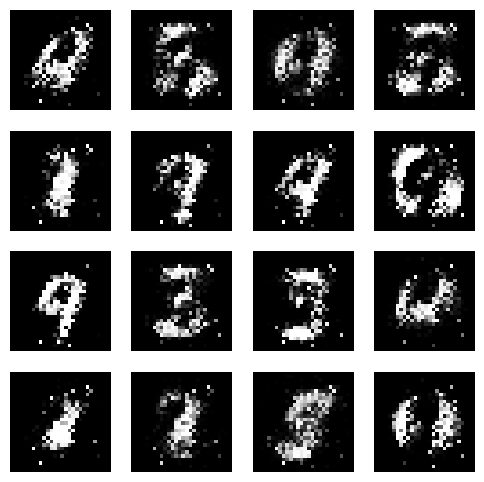

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i,:,:,0], cmap="gray")
    ax.axis("off")

plt.show()